In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


RANDOM_STATE = 42

In [2]:
train_df = pd.read_csv("train.csv")

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [6]:
# Percentage of missing values in each column
missing_pct = (train_df.isnull().mean() * 100).round(2)
print(missing_pct)

policy_id                           0.0
policy_tenure                       0.0
age_of_car                          0.0
age_of_policyholder                 0.0
area_cluster                        0.0
population_density                  0.0
make                                0.0
segment                             0.0
model                               0.0
fuel_type                           0.0
max_torque                          0.0
max_power                           0.0
engine_type                         0.0
airbags                             0.0
is_esc                              0.0
is_adjustable_steering              0.0
is_tpms                             0.0
is_parking_sensors                  0.0
is_parking_camera                   0.0
rear_brakes_type                    0.0
displacement                        0.0
cylinder                            0.0
transmission_type                   0.0
gear_box                            0.0
steering_type                       0.0


In [3]:
import pandas as pd

# Select numeric columns only
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('is_claim', errors='ignore')


outlier_summary = {}

for col in num_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'policy_tenure': 0,
 'age_of_car': 269,
 'age_of_policyholder': 221,
 'population_density': 3647,
 'make': 0,
 'airbags': 0,
 'displacement': 0,
 'cylinder': 0,
 'gear_box': 14381,
 'turning_radius': 0,
 'length': 0,
 'width': 0,
 'height': 0,
 'gross_weight': 0,
 'ncap_rating': 0}

In [ ]:
# for col in outlier_summary:
#     print(col, train_df[col].describe())

# Outlier Removal 

In [4]:
df = train_df.copy()

# columns that actually have outliers
cols_with_outliers = [col for col, cnt in outlier_summary.items() if cnt > 0]

print("Columns with outliers:", cols_with_outliers)

def drop_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:
            continue

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

train_df_clean = drop_outliers_iqr(df, cols_with_outliers)

print("Original shape:", train_df.shape)
print("After dropping outliers:", train_df_clean.shape)

Columns with outliers: ['age_of_car', 'age_of_policyholder', 'population_density', 'gear_box']
Original shape: (58592, 44)
After dropping outliers: (54480, 44)


In [5]:
# Convert appropriate columns to numeric types
train_df_clean['policy_tenure'] = pd.to_numeric(train_df_clean['policy_tenure'], errors='coerce')
train_df_clean['age_of_car'] = pd.to_numeric(train_df_clean['age_of_car'], errors='coerce')
train_df_clean['age_of_policyholder'] = pd.to_numeric(train_df_clean['age_of_policyholder'], errors='coerce')
# train_df_clean['max_torque'] = train_df_clean['max_torque'].str.extract('(\d+\.?\d*)').astype(float)
if train_df_clean['max_torque'].dtype == 'object':
    train_df_clean['max_torque'] = (
        train_df_clean['max_torque']
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
    )
# train_df_clean['max_power'] = train_df_clean['max_power'].str.extract('(\d+\.?\d*)').astype(float)
if train_df_clean['max_power'].dtype == 'object':
    train_df_clean['max_power'] = (
        train_df_clean['max_power']
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
    )
train_df_clean['displacement'] = pd.to_numeric(train_df_clean['displacement'], errors='coerce')  

In [6]:
# Handle remaining boolean and categorical columns
boolean_columns = ['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights',
                   'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
                   'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']
for col in boolean_columns:
    train_df_clean[col] = train_df_clean[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Data Transformation

Data Encoding

In [7]:
train_df_clean.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,0,0,0,1,0,0,0,1,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,0,0,0,1,0,0,0,1,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,0,0,0,1,0,0,0,1,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,1,1,1,1,1,1,1,1,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,0,1,1,1,0,1,1,1,2,0


In [8]:
 #Drop policy_id 
if 'policy_id' in train_df_clean.columns:
    train_df_clean = train_df_clean.drop(columns=['policy_id'])

In [11]:
df_enc = train_df_clean.copy()
# Columns that are already normalized 
pre_normalized_cols = ['policy_tenure', 'age_of_car', 'age_of_policyholder']

# 1) Label-encode remaining categorical columns (excluding boolean + target)
cat_cols = df_enc.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in boolean_columns and c != 'is_claim']

le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

In [49]:
# 1. Train–test split 
# ============================================
X = df_enc.drop('is_claim', axis=1)
y = df_enc['is_claim']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================
# 2. Min–Max scaling on numeric columns 
# ============================================
pre_normalized_cols = ['policy_tenure', 'age_of_car', 'age_of_policyholder']
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [
    c for c in numeric_cols
    if c not in boolean_columns and c not in pre_normalized_cols
]

scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test_scaled[numeric_cols])

# Data Imbalance Treatment

In [50]:
# X_train_scaled, y_train = X_train_scaled.groupby(y_train).apply(lambda g: g.sample(5000) if g.shape[0] > 5000 else g).reset_index(level=0, drop=True), y_train.groupby(y_train).apply(lambda g: g.sample(5000) if g.shape[0] > 5000 else g).reset_index(level=0, drop=True)


In [54]:
# ============================================
# 3. Apply SMOTE on the *training set only*
# ============================================
smote = SMOTE(random_state=42, sampling_strategy='auto')

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("=== Original Train Distribution ===")
print("Counts:")
print(y_train.value_counts())
print("\nPercentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\n=== After SMOTE Distribution ===")
print("Counts:")
print(y_train_res.value_counts())
print("\nPercentage:")
print((y_train_res.value_counts(normalize=True) * 100).round(2))

=== Original Train Distribution ===
Counts:
is_claim
0    40748
1     2836
Name: count, dtype: int64

Percentage:
is_claim
0    93.49
1     6.51
Name: proportion, dtype: float64

=== After SMOTE Distribution ===
Counts:
is_claim
0    40748
1    40748
Name: count, dtype: int64

Percentage:
is_claim
0    50.0
1    50.0
Name: proportion, dtype: float64


In [34]:
X_train_res.shape

(81496, 42)

# Feature Selection

C:\Users\Arpita\AppData\Local\Temp\ipykernel_43736\2209591895.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


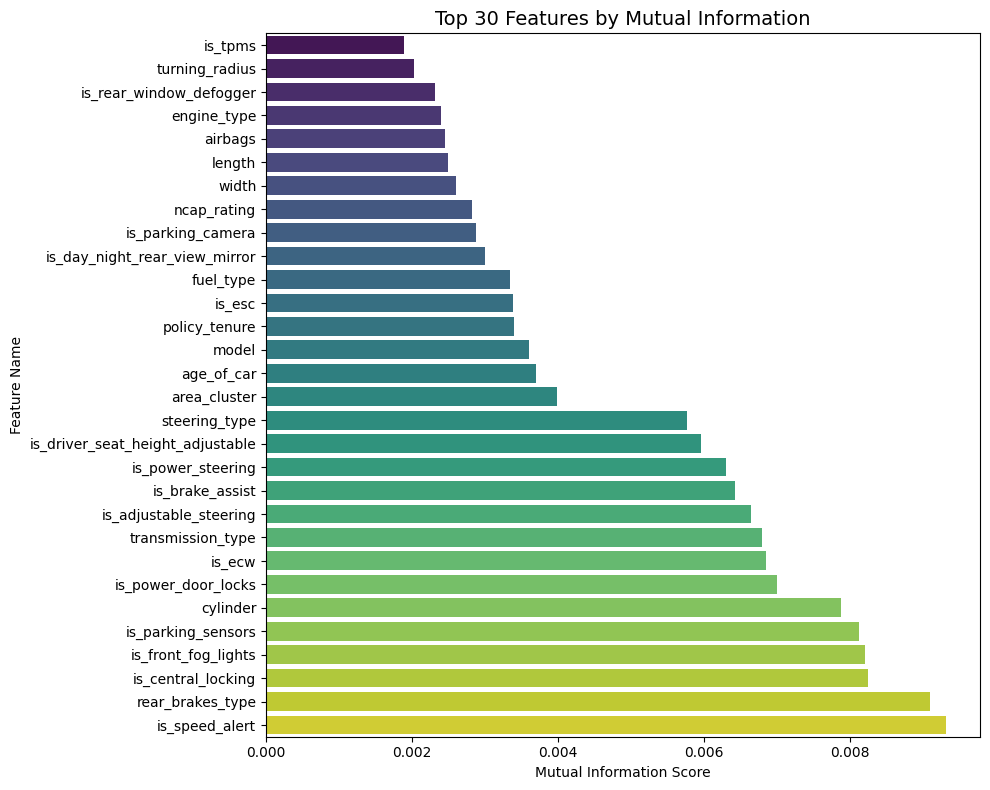

In [57]:
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns

mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)

mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores
})

# Sort in descending order
mi_df = mi_df.sort_values(by='mi_score', ascending=False)

# Select top 20 features
# top_20_features = mi_df.head(20)

# print("Top 20 Features Based on Mutual Information:")
# print(top_20_features)

# Take the top 20 from the previously computed mi_df
top20 = mi_df.head(30).sort_values(by='mi_score', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20,
    x='mi_score',
    y='feature',
    palette='viridis'   # colorful gradient palette
)

plt.title("Top 30 Features by Mutual Information", fontsize=14)
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.savefig("top30_mutual_information.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
# y_test.value_counts()

In [40]:
# mi_df.to_csv("selected_features.csv",index=False)

# Model Training

In [64]:
top_features = mi_df.head(30)

USE_TOP_FEATURES = True

if USE_TOP_FEATURES:
    selected_features = top_features["feature"].tolist()
else:
    selected_features = X_train_res.columns.tolist()

X_train_final = X_train_res[selected_features].copy()
X_test_final  = X_test_scaled[selected_features].copy()

print("Number of features used:", len(selected_features))

Number of features used: 30


In [65]:
def compute_metrics(y_true, y_pred, y_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
    else:
        auc = np.nan

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
    }

In [66]:
def train_model_with_grid(name, base_estimator, param_grid,
                          X_train, y_train, X_test, y_test,
                          scoring="roc_auc", cv=5):
 
    print(f"\n>>> Grid search for {name}")

    grid = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )

    with tqdm(total=1, desc=f"GridSearch {name}") as pbar:
        grid.fit(X_train, y_train)
        pbar.update()

    best_params = grid.best_params_
    print(f"\nBest params for {name}: {best_params}")
    print(f"Best CV {scoring} for {name}: {grid.best_score_:.4f}")

    # Re-initialize a fresh model with best params
    base_cls = base_estimator.__class__
    base_kwargs = base_estimator.get_params()
    base_kwargs.update(best_params)
    best_model = base_cls(**base_kwargs)

    print(f"\n>>> Training {name} with best params")
    with tqdm(total=1, desc=f"Fit {name}") as pbar:
        best_model.fit(X_train, y_train)
        pbar.update()

    # Predictions
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    metrics = compute_metrics(y_test, y_pred, y_proba)

    print(f"\n==== {name} (best) ====")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    # print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Package with model name
    metrics_with_name = {"model": name}
    metrics_with_name.update(metrics)

    return best_model, best_params, metrics_with_name, grid

def train_stacking_with_best(xgb_params, lgbm_params,
                             X_train, y_train, X_test, y_test):
    
    # Re-init base learners (fresh)
    xgb_stack = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **xgb_params,
    )

    lgbm_stack = LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **lgbm_params,
    )

    stack_meta = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )

    stack_estimators = [
        ("xgb", xgb_stack),
        ("lgbm", lgbm_stack),
    ]

    stack_model = StackingClassifier(
        estimators=stack_estimators,
        final_estimator=stack_meta,
        n_jobs=-1,
        passthrough=False,
    )

    print("\n>>> Training Stacking Ensemble (XGB + LGBM)")
    with tqdm(total=1, desc="Fit Stacking") as pbar:
        stack_model.fit(X_train, y_train)
        pbar.update()

    y_pred = stack_model.predict(X_test)
    y_proba = stack_model.predict_proba(X_test)[:, 1]

    metrics = compute_metrics(y_test, y_pred, y_proba)

    # print("\n==== Stacking (XGB + LGBM) ====")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    # print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    metrics_with_name = {"model": "Stacking (XGB + LGBM)"}
    metrics_with_name.update(metrics)

    return stack_model, metrics_with_name

In [67]:
# Logistic Regression
log_base = LogisticRegression(
    random_state=RANDOM_STATE ,
    solver="liblinear"
)

log_param_grid = {
    "penalty": ["l1", "l2"]
}

# XGBoost
xgb_base = XGBClassifier(
    objective="binary:logistic",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_param_grid = {
    "learning_rate": [0.01, 0.001],
    "max_depth": [3, 5, 7, 10],
}

# LightGBM
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm_param_grid = {
    "learning_rate": [0.01, 0.001],
    "max_depth": [3, 5, 7, 10],
}

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_grid = {
    "max_depth": [ 5, 10, 20],
    "min_samples_split": [2, 5, 10],
} 

In [68]:
log_best_model, log_best_params, log_results, log_grid = train_model_with_grid(
    name="Logistic Regression",
    base_estimator=log_base,
    param_grid=log_param_grid,
    X_train=X_train_final,
    y_train=y_train_res,
    X_test=X_test_final,
    y_test=y_test,
)

xgb_best_model, xgb_best_params, xgb_results, xgb_grid = train_model_with_grid(
    name="XGBoost",
    base_estimator=xgb_base,
    param_grid=xgb_param_grid,
    X_train=X_train_final,
    y_train=y_train_res,
    X_test=X_test_final,
    y_test=y_test,
)

# lgbm_best_model, lgbm_best_params, lgbm_results, lgbm_grid = train_model_with_grid(
#     name="LightGBM",
#     base_estimator=lgbm_base,
#     param_grid=lgbm_param_grid,
#     X_train=X_train_final,
#     y_train=y_train_res,
#     X_test=X_test_final,
#     y_test=y_test,
# )

rf_best_model, rf_best_params, rf_results, rf_grid = train_model_with_grid(
    name="Random Forest",
    base_estimator=rf_base,
    param_grid=rf_param_grid,
    X_train=X_train_final,
    y_train=y_train_res,
    X_test=X_test_final,
    y_test=y_test,
)


# stack_model, stack_results = train_stacking_with_best(
#     xgb_params=xgb_best_params,
#     lgbm_params=lgbm_best_params,
#     X_train=X_train_final,
#     y_train=y_train_res,
#     X_test=X_test_final,
#     y_test=y_test,
# )

all_results = pd.DataFrame([
    log_results,
    xgb_results,
    rf_results
    # lgbm_results,
    # stack_results,
])

print("\n==== Summary of model performance ====")
all_results


>>> Grid search for Logistic Regression


GridSearch Logistic Regression:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best params for Logistic Regression: {'penalty': 'l2'}
Best CV roc_auc for Logistic Regression: 0.6108

>>> Training Logistic Regression with best params


Fit Logistic Regression:   0%|          | 0/1 [00:00<?, ?it/s]


==== Logistic Regression (best) ====
accuracy  : 0.5651
precision : 0.0825
recall    : 0.5614
f1        : 0.1438
roc_auc   : 0.5975

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.57      0.71     10187
           1       0.08      0.56      0.14       709

    accuracy                           0.57     10896
   macro avg       0.52      0.56      0.43     10896
weighted avg       0.89      0.57      0.67     10896

[[5759 4428]
 [ 311  398]]

>>> Grid search for XGBoost


...

GridSearch Random Forest:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best params for Random Forest: {'max_depth': 20, 'min_samples_split': 5}
Best CV roc_auc for Random Forest: 0.9306

>>> Training Random Forest with best params


Fit Random Forest:   0%|          | 0/1 [00:00<?, ?it/s]


==== Random Forest (best) ====
accuracy  : 0.7641
precision : 0.0928
recall    : 0.2990
f1        : 0.1416
roc_auc   : 0.5898

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     10187
           1       0.09      0.30      0.14       709

    accuracy                           0.76     10896
   macro avg       0.52      0.55      0.50     10896
weighted avg       0.89      0.76      0.82     10896

[[8114 2073]
 [ 497  212]]

==== Summary of model performance ====


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.565070,0.082470,0.561354,0.143812,0.597471
1,XGBoost,0.805250,0.109884,0.280677,0.157937,0.617932
2,Random Forest,0.764134,0.092779,0.299013,0.141617,0.589769


In [63]:
# all_results.to_csv('initial_res.csv',index=False)